In [1]:
# ============================================================
# 1. KHAI BÁO THƯ VIỆN
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# Để 1 cho máy chạy ổn định, hạn chế treo Jupyter
N_JOBS = 1

pd.set_option("display.max_columns", 30)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)

print("Đã khai báo thư viện thành công.")


Đã khai báo thư viện thành công.


In [2]:
# ============================================================
# 2. KHAI BÁO BIẾN NGHIÊN CỨU
# ============================================================

FEATURES = [
    "LNST",
    "ROA",
    "CR",
    "Size",
    "DR",
    "Asset_Growth",
    "profit_growth"
]

TARGET = "Target_Up"

TEST_YEARS = [
    2022,
    2023,
    2024
]

REQUIRED_COLUMNS = [
    "Ticker",
    "Date",
    "Price_Close"
] + FEATURES

print("Số biến đầu vào:", len(FEATURES))
print("Các biến đầu vào:", FEATURES)
print("Biến mục tiêu:", TARGET)
print("Các năm kiểm tra:", TEST_YEARS)

Số biến đầu vào: 7
Các biến đầu vào: ['LNST', 'ROA', 'CR', 'Size', 'DR', 'Asset_Growth', 'profit_growth']
Biến mục tiêu: Target_Up
Các năm kiểm tra: [2022, 2023, 2024]


In [3]:
# ============================================================
# 3. ĐỌC DỮ LIỆU
# ============================================================

file_path = Path("dl9.xlsx")

if not file_path.exists():
    raise FileNotFoundError(
        "Không tìm thấy file dl9.xlsx. "
        "Hãy đặt file Excel cùng thư mục với notebook."
    )

df = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

# Xóa khoảng trắng thừa trong tên cột
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

# Đổi tên hai cột đầu nếu Excel đang để Unnamed
df = df.rename(columns={
    "Unnamed: 0": "Ticker",
    "Unnamed: 1": "Date"
})

print("Kích thước dữ liệu ban đầu:", df.shape)
display(df.head())

Kích thước dữ liệu ban đầu: (7700, 17)


,Ticker,Date,Price_Close,LNST,TTS,ROA,ROE,CR,Debt,Size,DR,Asset_Growth,profit_growth,equity,D/E,FL,Y (return)
0,CHP.HM,2015-12-31,"7,789.6532","213,069,688,936.0000","3,321,660,207,576.0000",6.3315,15.9296,0.9484,"1,615,223,490,334.0000",28.8315,0.4863,NaN,NaN,"1,706,436,717,242.0000",0.9465,1.9465,NaN
1,CHP.HM,2016-12-31,"8,463.3530","328,301,148,300.0000","3,255,272,050,418.0000",9.9834,21.5481,1.4767,"1,445,223,490,334.0000",28.8113,0.4440,-0.0200,0.5408,"1,810,048,560,084.0000",0.7984,1.7984,0.0865
2,CHP.HM,2017-12-31,"11,597.2246","257,774,803,645.0000","3,083,762,913,778.0000",8.1329,15.6405,1.6152,"1,281,423,490,334.0000",28.7572,0.4155,-0.0527,-0.2148,"1,802,339,423,444.0000",0.7110,1.7110,0.3703
3,CHP.HM,2018-12-31,"10,421.8337","410,334,082,470.0000","3,105,531,101,221.0000",13.9724,24.3668,2.4201,"1,117,623,490,334.0000",28.7642,0.3599,0.0071,0.5918,"1,987,907,610,887.0000",0.5622,1.5622,-0.1014
4,CHP.HM,2019-12-31,"10,661.4933","95,892,316,467.0000","2,848,966,843,318.0000",3.3922,5.5494,1.6046,"979,023,490,334.0000",28.6780,0.3436,-0.0826,-0.7663,"1,869,943,352,984.0000",0.5236,1.5236,0.0230


In [4]:
# ============================================================
# 4. KIỂM TRA CỘT VÀ CHỈ GIỮ BIẾN CẦN DÙNG
# ============================================================

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "File Excel đang thiếu các cột: "
        + ", ".join(missing_columns)
    )

# Chỉ giữ các biến thực sự dùng
df = df[REQUIRED_COLUMNS].copy()

print("Kích thước sau khi chỉ giữ biến cần dùng:", df.shape)
print("Các cột còn lại:")
print(df.columns.tolist())

Kích thước sau khi chỉ giữ biến cần dùng: (7700, 10)
Các cột còn lại:
['Ticker', 'Date', 'Price_Close', 'LNST', 'ROA', 'CR', 'Size', 'DR', 'Asset_Growth', 'profit_growth']


In [5]:
# ============================================================
# 5. CHUẨN HÓA DỮ LIỆU
# ============================================================

df["Ticker"] = (
    df["Ticker"]
    .astype(str)
    .str.strip()
)

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Year"] = df["Date"].dt.year

# Chuyển các biến tài chính về dạng số
numeric_columns = [
    "Price_Close"
] + FEATURES

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Thay giá trị vô cực bằng NaN
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Bỏ dòng không có mã hoặc không có năm
df = df.dropna(
    subset=[
        "Ticker",
        "Year"
    ]
)

df["Year"] = df["Year"].astype(int)

# Sắp xếp dữ liệu
df = df.sort_values(
    [
        "Ticker",
        "Date"
    ]
)

# Nếu một mã có nhiều dòng trong cùng năm,
# giữ quan sát cuối năm
df = df.drop_duplicates(
    subset=[
        "Ticker",
        "Year"
    ],
    keep="last"
)

df = df.reset_index(drop=True)

print("Kích thước dữ liệu sau chuẩn hóa:", df.shape)

print(
    "Khoảng thời gian:",
    df["Year"].min(),
    "đến",
    df["Year"].max()
)

print(
    "Số mã cổ phiếu:",
    df["Ticker"].nunique()
)

display(df.head())

Kích thước dữ liệu sau chuẩn hóa: (7700, 11)
Khoảng thời gian: 2015 đến 2025
Số mã cổ phiếu: 700


,Ticker,Date,Price_Close,LNST,ROA,CR,Size,DR,Asset_Growth,profit_growth,Year
0,AAA.HM,2015-12-31,"6,259.5065","89,265,995,959.0000",8.2107,9.1283,28.4188,0.0623,NaN,NaN,2015
1,AAA.HM,2016-12-31,"12,866.7502","210,684,062,435.0000",7.7944,7.9935,29.1921,0.0296,1.1669,1.3602,2016
2,AAA.HM,2017-12-31,"19,211.0612","135,674,849,362.0000",3.0720,4.7366,29.5341,0.0260,0.4078,-0.3560,2017
3,AAA.HM,2018-12-31,"11,076.3766","228,519,843,820.0000",4.1566,4.9283,29.5671,0.0214,0.0336,0.6843,2018
4,AAA.HM,2019-12-31,"9,852.5082","379,111,428,571.0000",5.3111,2.6054,30.0468,0.0099,0.6155,0.6590,2019


In [6]:
# ============================================================
# 6. KIỂM TRA DỮ LIỆU THIẾU
# ============================================================

analysis_columns = [
    "Ticker",
    "Date",
    "Year",
    "Price_Close"
] + FEATURES

missing_table = pd.DataFrame({
    "Số lượng thiếu":
        df[analysis_columns].isna().sum(),

    "Tỷ lệ thiếu":
        df[analysis_columns].isna().mean()
})

missing_table = missing_table.sort_values(
    "Tỷ lệ thiếu",
    ascending=False
)

print("Bảng dữ liệu thiếu:")
display(missing_table)

Bảng dữ liệu thiếu:


,Số lượng thiếu,Tỷ lệ thiếu
Asset_Growth,810,0.1052
DR,803,0.1043
profit_growth,792,0.1029
Price_Close,658,0.0855
ROA,287,0.0373
CR,111,0.0144
Size,66,0.0086
LNST,57,0.0074
Ticker,0,0.0000
Date,0,0.0000


,count,mean,std,min,1%,25%,50%,75%,99%,max,Missing_Rate
Price_Close,"7,042.0000","17,624.0796","21,193.5622",108.8372,"1,700.0000","6,665.1186","11,200.0000","20,048.6756","102,874.0873","288,200.0000",0.0855
LNST,"7,643.0000","471,431,353,148.0328","2,234,243,227,796.6787","-13,278,992,876,131.0000","-127,631,039,184.7600","10,164,653,493.5000","39,955,753,119.0000","163,869,632,168.0000","9,421,612,755,294.4980","43,334,776,000,000.0000",0.0074
ROA,"7,413.0000",7.4670,9.1160,-69.0073,-10.3104,2.0427,5.3863,10.7807,41.4867,112.9432,0.0373
CR,"7,589.0000",3.4986,14.2954,0.0338,0.4188,1.1781,1.6276,2.6999,34.4346,982.4858,0.0144
Size,"7,634.0000",27.8854,1.9292,23.3216,24.3254,26.5492,27.6886,28.8747,33.8583,35.7420,0.0086
DR,"6,897.0000",7.4611,71.5070,0.0000,0.0000,0.0167,0.1928,1.3240,115.3774,"2,747.8455",0.1043
Asset_Growth,"6,890.0000",1.8492,64.7426,-1.0000,-0.9836,-0.0440,0.0523,0.1947,9.1267,"4,760.6811",0.1052
profit_growth,"6,908.0000",89.4405,"7,971.6773","-83,695.5000",-7.7778,-0.3007,0.0676,0.5874,46.5639,"656,062.4381",0.1029


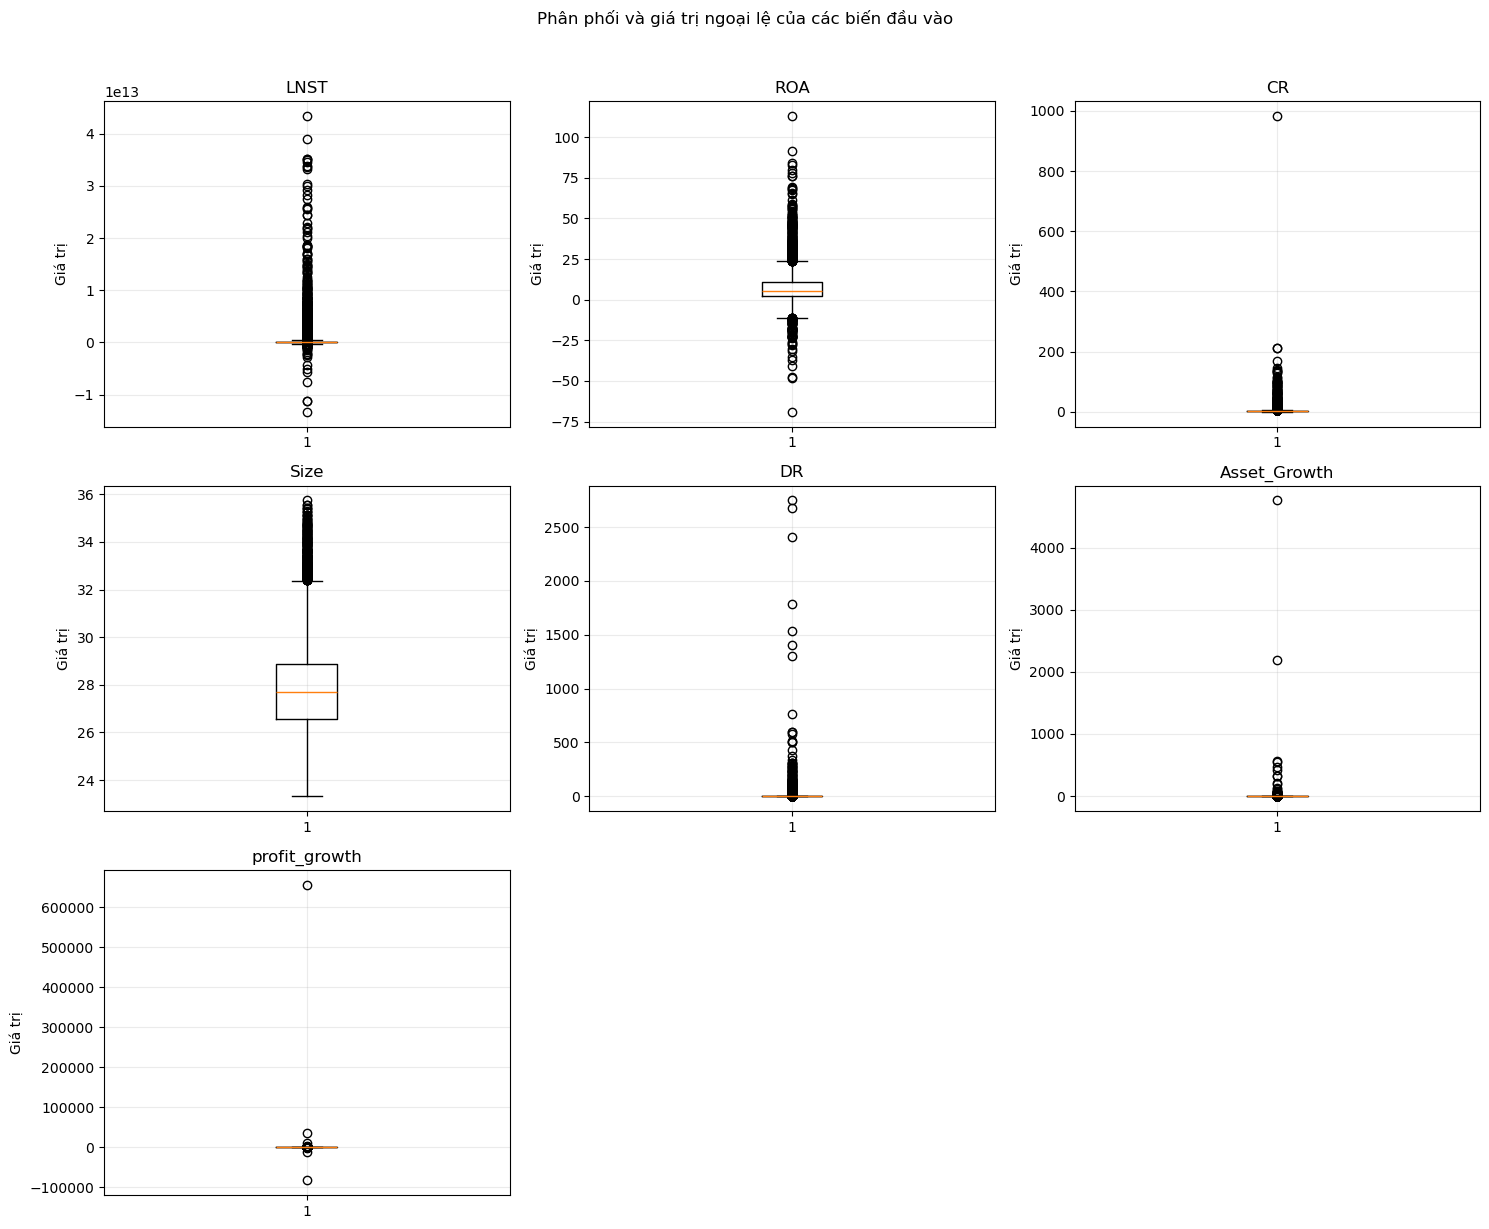

In [7]:
# ============================================================
# 7. THỐNG KÊ MÔ TẢ VÀ PHÂN PHỐI BIẾN
# ============================================================

descriptive_statistics = (
    df[["Price_Close"] + FEATURES]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

descriptive_statistics["Missing_Rate"] = (
    df[["Price_Close"] + FEATURES].isna().mean()
)

display(descriptive_statistics)

# Biểu đồ hộp để phát hiện ngoại lệ.
# Dùng log1p cho các biến không âm và có độ lệch lớn chỉ nhằm mục đích trực quan.
plot_df = df[FEATURES].copy()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(FEATURES):
    values = plot_df[feature].dropna()
    axes[i].boxplot(values, vert=True)
    axes[i].set_title(feature)
    axes[i].set_ylabel("Giá trị")
    axes[i].grid(alpha=0.25)

for j in range(len(FEATURES), len(axes)):
    axes[j].axis("off")

plt.suptitle("Phân phối và giá trị ngoại lệ của các biến đầu vào", y=1.02)
plt.tight_layout()
plt.show()


In [8]:
# Số quan sát theo năm

observations_by_year = (
    df.groupby("Year")
    .size()
    .rename("Số quan sát")
    .to_frame()
)
print("Số quan sát theo năm:")
display(observations_by_year)

Số quan sát theo năm:


,Số quan sát
Year,
2015,700
2016,700
2017,700
2018,700
2019,700
2020,700
2021,700
2022,700
2023,700


### Nhận xét
Số quan sát phân bố tương đối đều theo các năm trước khi xây dựng biến mục tiêu. Tuy nhiên, do nhãn được tạo từ giá của năm kế tiếp, các quan sát năm cuối không thể tạo nhãn và sẽ bị loại khỏi dữ liệu mô hình.


In [9]:
# ============================================================
# 8. TẠO BIẾN MỤC TIÊU
# ============================================================

# Xác định năm tiếp theo của cùng mã cổ phiếu
df["Future_Year"] = (
    df.groupby("Ticker")["Year"]
    .shift(-1)
)

# Giá đóng cửa năm tiếp theo
df["Future_Price"] = (
    df.groupby("Ticker")["Price_Close"]
    .shift(-1)
)

# Khoảng cách giữa hai năm
df["Year_Gap"] = (
    df["Future_Year"]
    - df["Year"]
)

# Chỉ tạo nhãn khi hai năm liên tiếp nhau
valid_next_year = (
    (df["Year_Gap"] == 1)
    & df["Price_Close"].notna()
    & df["Future_Price"].notna()
)

df["Target_Up"] = np.nan

df.loc[
    valid_next_year,
    "Target_Up"
] = (
    df.loc[
        valid_next_year,
        "Future_Price"
    ]
    >
    df.loc[
        valid_next_year,
        "Price_Close"
    ]
).astype(int)

In [10]:
# Chỉ giữ những dòng tạo được nhãn

model_columns = [
    "Ticker",
    "Date",
    "Year",
    "Price_Close",
    "Future_Year",
    "Future_Price",
    "Target_Up"
] + FEATURES

model_df = (
    df.loc[
        df["Target_Up"].notna(),
        model_columns
    ]
    .copy()
)

model_df["Target_Up"] = (
    model_df["Target_Up"]
    .astype(int)
)

print(
    "Kích thước dữ liệu mô hình:",
    model_df.shape
)

print(
    "Khoảng năm có thể dùng làm biến đầu vào:",
    model_df["Year"].min(),
    "đến",
    model_df["Year"].max()
)

display(model_df.head())

Kích thước dữ liệu mô hình: (6342, 14)
Khoảng năm có thể dùng làm biến đầu vào: 2015 đến 2024


,Ticker,Date,Year,Price_Close,Future_Year,Future_Price,Target_Up,LNST,ROA,CR,Size,DR,Asset_Growth,profit_growth
0,AAA.HM,2015-12-31,2015,"6,259.5065","2,016.0000","12,866.7502",1,"89,265,995,959.0000",8.2107,9.1283,28.4188,0.0623,NaN,NaN
1,AAA.HM,2016-12-31,2016,"12,866.7502","2,017.0000","19,211.0612",1,"210,684,062,435.0000",7.7944,7.9935,29.1921,0.0296,1.1669,1.3602
2,AAA.HM,2017-12-31,2017,"19,211.0612","2,018.0000","11,076.3766",0,"135,674,849,362.0000",3.0720,4.7366,29.5341,0.0260,0.4078,-0.3560
3,AAA.HM,2018-12-31,2018,"11,076.3766","2,019.0000","9,852.5082",0,"228,519,843,820.0000",4.1566,4.9283,29.5671,0.0214,0.0336,0.6843
4,AAA.HM,2019-12-31,2019,"9,852.5082","2,020.0000","12,216.6378",1,"379,111,428,571.0000",5.3111,2.6054,30.0468,0.0099,0.6155,0.6590


In [11]:
# ============================================================
# 9. PHÂN BỐ BIẾN MỤC TIÊU
# ============================================================

target_distribution = (
    model_df["Target_Up"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Không tăng hoặc giảm",
        1: "Tăng giá"
    })
    .to_frame("Số lượng")
)

target_distribution["Tỷ lệ"] = (
    target_distribution["Số lượng"]
    / target_distribution["Số lượng"].sum()
)

display(target_distribution)

,Số lượng,Tỷ lệ
Target_Up,,
Không tăng hoặc giảm,2659,0.4193
Tăng giá,3683,0.5807


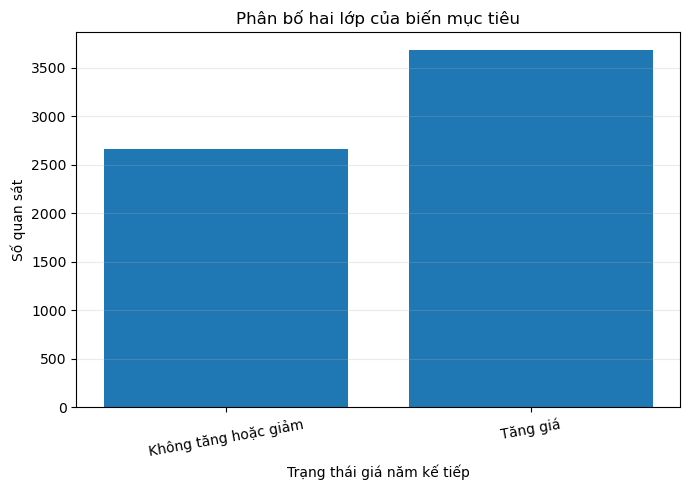

Tỷ lệ lớp 0: 0.4193
Tỷ lệ lớp 1: 0.5807
Nhận xét: Nếu tỷ lệ hai lớp chênh lệch đáng kể, không nên chỉ dựa vào Accuracy; cần ưu tiên Macro F1, Recall từng lớp và ROC-AUC.


In [12]:
# Biểu đồ mức độ cân bằng của biến mục tiêu
plt.figure(figsize=(7, 5))
plt.bar(
    target_distribution.index,
    target_distribution["Số lượng"]
)
plt.title("Phân bố hai lớp của biến mục tiêu")
plt.xlabel("Trạng thái giá năm kế tiếp")
plt.ylabel("Số quan sát")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

class_ratio = model_df[TARGET].value_counts(normalize=True).sort_index()
print("Tỷ lệ lớp 0:", round(class_ratio.get(0, 0), 4))
print("Tỷ lệ lớp 1:", round(class_ratio.get(1, 0), 4))
print(
    "Nhận xét: Nếu tỷ lệ hai lớp chênh lệch đáng kể, "
    "không nên chỉ dựa vào Accuracy; cần ưu tiên Macro F1, Recall từng lớp và ROC-AUC."
)


In [13]:
# Phân bố mục tiêu theo năm

target_by_year = pd.crosstab(
    model_df["Year"],
    model_df["Target_Up"]
)

target_by_year = target_by_year.rename(
    columns={
        0: "Không tăng hoặc giảm",
        1: "Tăng giá"
    }
)

for column in [
    "Không tăng hoặc giảm",
    "Tăng giá"
]:
    if column not in target_by_year.columns:
        target_by_year[column] = 0

target_by_year["Tổng"] = (
    target_by_year.sum(axis=1)
)

target_by_year["Tỷ lệ tăng giá"] = (
    target_by_year["Tăng giá"]
    / target_by_year["Tổng"]
)

display(target_by_year)

Target_Up,Không tăng hoặc giảm,Tăng giá,Tổng,Tỷ lệ tăng giá
Year,,,,
2015,190,312,502,0.6215
2016,187,351,538,0.6524
2017,352,244,596,0.4094
2018,292,343,635,0.5402
2019,186,461,647,0.7125
2020,69,596,665,0.8962
2021,563,118,681,0.1733
2022,220,470,690,0.6812
2023,300,391,691,0.5658


### Nhận xét
Dữ liệu có sự chênh lệch giữa hai lớp nhưng chưa mất cân bằng nghiêm trọng. Đáng chú ý, tỷ lệ cổ phiếu tăng biến động mạnh giữa các năm, phản ánh sự thay đổi của điều kiện thị trường. Vì vậy, chia dữ liệu theo thời gian phù hợp hơn chia ngẫu nhiên và Macro F1 được chọn làm chỉ tiêu đánh giá chính.


In [14]:
# ============================================================
# 10. MA TRẬN TƯƠNG QUAN SPEARMAN
# ============================================================

correlation_matrix = (
    model_df[FEATURES]
    .corr(method="spearman")
)

display(correlation_matrix)

,LNST,ROA,CR,Size,DR,Asset_Growth,profit_growth
LNST,1.0000,0.3267,0.0271,0.7225,-0.3575,0.2822,0.3090
ROA,0.3267,1.0000,0.0261,-0.1216,0.0857,0.0219,0.1444
CR,0.0271,0.0261,1.0000,-0.0027,0.0284,-0.0034,-0.0043
Size,0.7225,-0.1216,-0.0027,1.0000,-0.5025,0.2579,0.1109
DR,-0.3575,0.0857,0.0284,-0.5025,1.0000,-0.1204,-0.0477
Asset_Growth,0.2822,0.0219,-0.0034,0.2579,-0.1204,1.0000,0.3337
profit_growth,0.3090,0.1444,-0.0043,0.1109,-0.0477,0.3337,1.0000


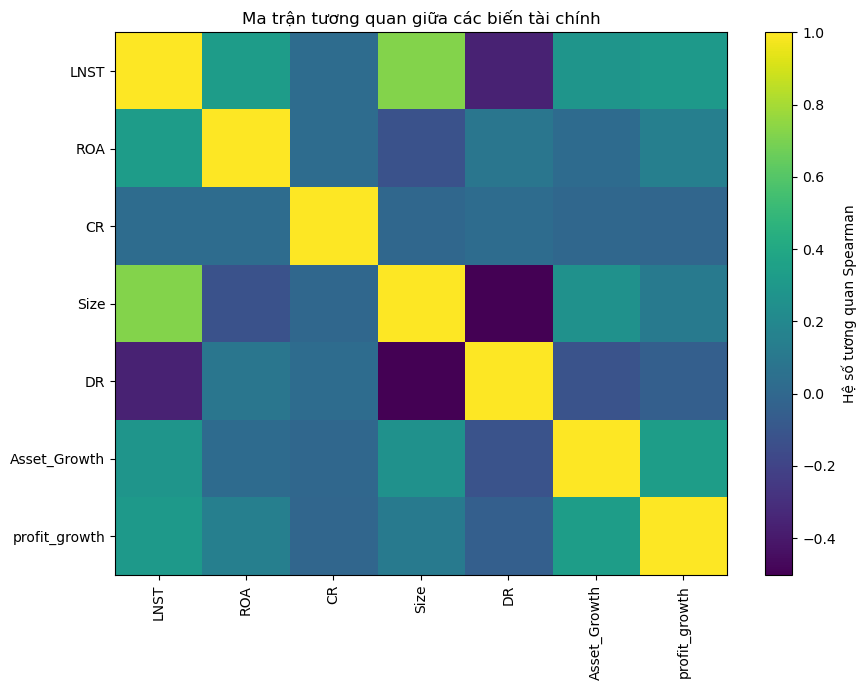

In [15]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Hệ số tương quan Spearman"
)

plt.xticks(
    range(len(FEATURES)),
    FEATURES,
    rotation=90
)

plt.yticks(
    range(len(FEATURES)),
    FEATURES
)

plt.title(
    "Ma trận tương quan giữa các biến tài chính"
)

plt.tight_layout()
plt.show()

In [16]:
# Kiểm tra các cặp có tương quan mạnh

high_corr_pairs = []

for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):

        corr_value = (
            correlation_matrix.iloc[i, j]
        )

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append({
                "Biến 1": FEATURES[i],
                "Biến 2": FEATURES[j],
                "Tương quan Spearman":
                    corr_value
            })

high_corr_table = pd.DataFrame(
    high_corr_pairs
)

print(
    "Các cặp biến có |tương quan| từ 0.80 trở lên:"
)

if high_corr_table.empty:
    print("Không có cặp biến nào vượt ngưỡng.")
else:
    display(high_corr_table)

Các cặp biến có |tương quan| từ 0.80 trở lên:
Không có cặp biến nào vượt ngưỡng.


### Nhận xét
Phần lớn các cặp biến có tương quan thấp hoặc trung bình. Tương quan đáng chú ý nhất là giữa LNST và Size, trong khi Size và DR có tương quan âm tương đối rõ. Chưa có bằng chứng cho thấy đa cộng tuyến nghiêm trọng, nên bảy biến tiếp tục được giữ lại để xây dựng mô hình.


In [17]:
# ============================================================
# 11. CHIA TRAIN VÀ TEST THEO NĂM
# ============================================================

def create_train_test_by_year(
    data,
    test_year,
    features,
    target
):
    train_data = data[
        data["Year"] < test_year
    ].copy()

    test_data = data[
        data["Year"] == test_year
    ].copy()

    if train_data.empty:
        raise ValueError(
            f"Không có dữ liệu train trước năm {test_year}."
        )

    if test_data.empty:
        raise ValueError(
            f"Không có dữ liệu test năm {test_year}."
        )

    X_train = train_data[features]
    y_train = train_data[target]

    X_test = test_data[features]
    y_test = test_data[target]

    return (
        X_train,
        X_test,
        y_train,
        y_test,
        train_data,
        test_data
    )

In [18]:
# Kiểm tra cách chia dữ liệu

for test_year in TEST_YEARS:

    (
        X_train,
        X_test,
        y_train,
        y_test,
        train_data,
        test_data
    ) = create_train_test_by_year(
        model_df,
        test_year,
        FEATURES,
        TARGET
    )

    print(
        f"Test năm {test_year}: "
        f"train {train_data['Year'].min()}–"
        f"{train_data['Year'].max()} "
        f"({len(X_train)} quan sát), "
        f"test {test_year} "
        f"({len(X_test)} quan sát)"
    )

Test năm 2022: train 2015–2021 (4264 quan sát), test 2022 (690 quan sát)
Test năm 2023: train 2015–2022 (4954 quan sát), test 2023 (691 quan sát)
Test năm 2024: train 2015–2023 (5645 quan sát), test 2024 (697 quan sát)


### Nhận xét
Cách chia walk-forward bảo đảm toàn bộ dữ liệu huấn luyện đều xảy ra trước năm kiểm tra. Thiết kế này hạn chế rò rỉ thông tin tương lai và mô phỏng gần hơn quy trình dự báo trong thực tế đầu tư.


In [19]:
# ============================================================
# 12. CROSS-VALIDATION THEO THỜI GIAN
# ============================================================

def create_year_based_cv(
    train_data,
    target,
    min_train_years=3
):
    years = sorted(
        train_data["Year"]
        .dropna()
        .unique()
    )

    splits = []

    for i in range(
        min_train_years,
        len(years)
    ):
        validation_year = years[i]
        training_years = years[:i]

        train_idx = np.where(
            train_data["Year"].isin(
                training_years
            )
        )[0]

        validation_idx = np.where(
            train_data["Year"]
            == validation_year
        )[0]

        if (
            len(train_idx) == 0
            or len(validation_idx) == 0
        ):
            continue

        y_train_fold = (
            train_data.iloc[train_idx][target]
        )

        y_validation_fold = (
            train_data.iloc[validation_idx][target]
        )

        # Cần đủ hai lớp trong mỗi fold
        if (
            y_train_fold.nunique() < 2
            or y_validation_fold.nunique() < 2
        ):
            continue

        splits.append(
            (
                train_idx,
                validation_idx
            )
        )

    if len(splits) < 2:
        raise ValueError(
            "Không đủ fold theo thời gian. "
            "Hãy kiểm tra phân bố biến mục tiêu theo năm."
        )

    return splits

In [20]:
# ============================================================
# 13. HÀM TÍNH CHỈ TIÊU
# ============================================================

def safe_roc_auc(
    y_true,
    y_score
):
    if pd.Series(y_true).nunique() < 2:
        return np.nan

    return roc_auc_score(
        y_true,
        y_score
    )

In [21]:
def get_model_score(
    model,
    X
):
    if hasattr(
        model,
        "predict_proba"
    ):
        return model.predict_proba(X)[:, 1]

    if hasattr(
        model,
        "decision_function"
    ):
        return model.decision_function(X)

    return (
        model.predict(X)
        .astype(float)
    )

In [22]:
def calculate_metrics(
    model_name,
    test_year,
    y_true,
    y_pred,
    y_score,
    y_train_true=None,
    y_train_pred=None
):
    result = {
        "Model": model_name,
        "Test_Year": test_year,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision_0":
            precision_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "Recall_0":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "F1_0":
            f1_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "Precision_1":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Recall_1":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "F1_1":
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "ROC_AUC":
            safe_roc_auc(
                y_true,
                y_score
            )
    }

    if (
        y_train_true is not None
        and y_train_pred is not None
    ):
        train_macro_f1 = f1_score(
            y_train_true,
            y_train_pred,
            average="macro",
            zero_division=0
        )

        result["Train_Macro_F1"] = (
            train_macro_f1
        )

        result["Overfit_Gap"] = (
            train_macro_f1
            - result["Macro_F1"]
        )

    return result

In [23]:
# ============================================================
# 14. HÀM WALK-FORWARD VÀ GRID SEARCH
# ============================================================

def evaluate_model_walk_forward(
    model_name,
    pipeline,
    data,
    test_years,
    features,
    target,
    param_grid=None
):
    all_results = []
    all_predictions = []
    all_best_params = []
    fitted_models = {}

    for test_year in test_years:

        (
            X_train,
            X_test,
            y_train,
            y_test,
            train_data,
            test_data
        ) = create_train_test_by_year(
            data,
            test_year,
            features,
            target
        )

        if param_grid is not None:

            time_cv = create_year_based_cv(
                train_data,
                target
            )

            grid_search = GridSearchCV(
                estimator=clone(pipeline),
                param_grid=param_grid,
                scoring="f1_macro",
                cv=time_cv,
                n_jobs=N_JOBS,
                refit=True,
                error_score="raise"
            )

            grid_search.fit(
                X_train,
                y_train
            )

            fitted_model = (
                grid_search.best_estimator_
            )

            best_params_row = {
                "Model": model_name,
                "Test_Year": test_year,
                "Best_CV_Macro_F1":
                    grid_search.best_score_
            }

            best_params_row.update(
                grid_search.best_params_
            )

            all_best_params.append(
                best_params_row
            )

        else:

            fitted_model = clone(
                pipeline
            )

            fitted_model.fit(
                X_train,
                y_train
            )

        y_train_pred = fitted_model.predict(
            X_train
        )

        y_test_pred = fitted_model.predict(
            X_test
        )

        y_test_score = get_model_score(
            fitted_model,
            X_test
        )

        metrics = calculate_metrics(
            model_name=model_name,
            test_year=test_year,
            y_true=y_test,
            y_pred=y_test_pred,
            y_score=y_test_score,
            y_train_true=y_train,
            y_train_pred=y_train_pred
        )

        all_results.append(
            metrics
        )

        prediction_df = test_data[
            [
                "Ticker",
                "Year",
                "Price_Close",
                "Future_Price",
                "Target_Up"
            ]
        ].copy()

        prediction_df["Model"] = (
            model_name
        )

        prediction_df["Predicted_Class"] = (
            y_test_pred
        )

        prediction_df["Score_Up"] = (
            y_test_score
        )

        all_predictions.append(
            prediction_df
        )

        fitted_models[test_year] = (
            fitted_model
        )

        print(
            f"Đã hoàn thành {model_name} "
            f"– test năm {test_year}"
        )

    results_df = pd.DataFrame(
        all_results
    )

    predictions_df = pd.concat(
        all_predictions,
        ignore_index=True
    )

    best_params_df = pd.DataFrame(
        all_best_params
    )

    return (
        results_df,
        predictions_df,
        best_params_df,
        fitted_models
    )

In [24]:
# ============================================================
# 15. BIỂU ĐỒ LỰA CHỌN K CHO KNN
# ============================================================

(
    X_train_k,
    X_test_k,
    y_train_k,
    y_test_k,
    train_data_k,
    test_data_k
) = create_train_test_by_year(
    model_df,
    test_year=2024,
    features=FEATURES,
    target=TARGET
)

time_cv_k = create_year_based_cv(
    train_data_k,
    TARGET
)

k_values = range(20, 41)

k_cv_mean = []
k_cv_std = []

for k in k_values:

    knn_k_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            RobustScaler()
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=k,
                weights="uniform",
                p=2
            )
        )
    ])

    cv_scores = cross_val_score(
        knn_k_pipeline,
        X_train_k,
        y_train_k,
        scoring="f1_macro",
        cv=time_cv_k,
        n_jobs=N_JOBS
    )

    k_cv_mean.append(
        cv_scores.mean()
    )

    k_cv_std.append(
        cv_scores.std()
    )

In [25]:
k_result_table = pd.DataFrame({
    "k": list(k_values),
    "CV_Macro_F1_Mean": k_cv_mean,
    "CV_Macro_F1_Std": k_cv_std
})

display(
    k_result_table.sort_values(
        "CV_Macro_F1_Mean",
        ascending=False
    ).head(10)
)

,k,CV_Macro_F1_Mean,CV_Macro_F1_Std
0,20,0.4494,0.0789
4,24,0.4444,0.0905
6,26,0.4436,0.0958
8,28,0.4431,0.1021
10,30,0.4427,0.1028
1,21,0.4420,0.0935
2,22,0.4406,0.0809
20,40,0.4398,0.1138
7,27,0.4388,0.1020
12,32,0.4382,0.1040


In [26]:
best_k_index = np.argmax(k_cv_mean)

best_k_chart = list(k_values)[best_k_index]

print(
    "k có Macro F1 cross-validation cao nhất:",
    best_k_chart
)

print(
    "Macro F1 trung bình:",
    round(
        k_cv_mean[best_k_index],
        4
    )
)

k có Macro F1 cross-validation cao nhất: 20
Macro F1 trung bình: 0.4494


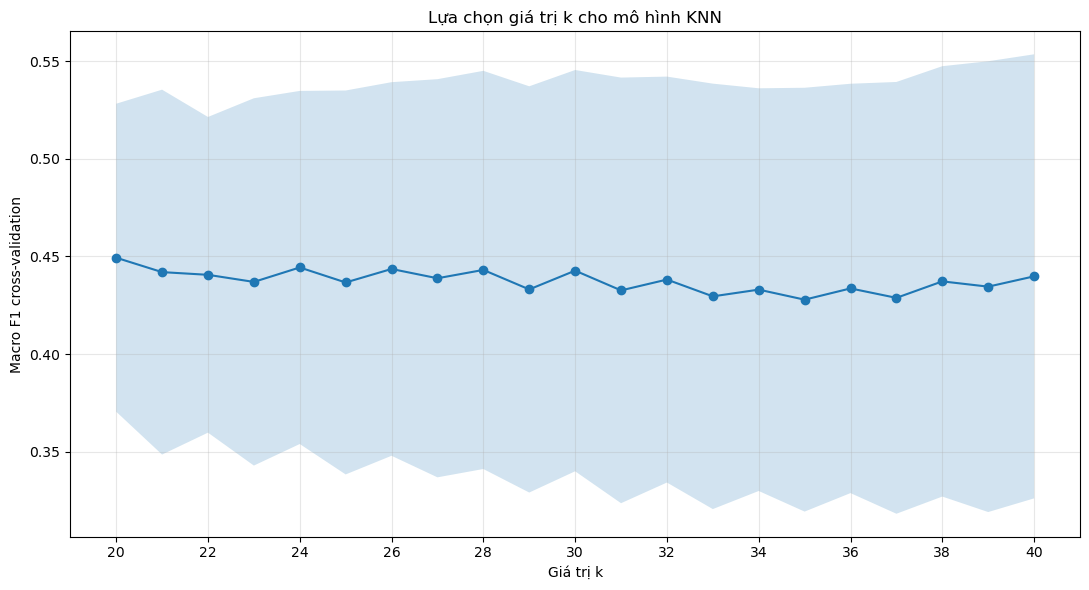

In [27]:
plt.figure(figsize=(11, 6))

plt.plot(
    list(k_values),
    k_cv_mean,
    marker="o"
)

plt.fill_between(
    list(k_values),
    np.array(k_cv_mean)
    - np.array(k_cv_std),
    np.array(k_cv_mean)
    + np.array(k_cv_std),
    alpha=0.2
)

plt.xlabel("Giá trị k")
plt.ylabel("Macro F1 cross-validation")

plt.title(
    "Lựa chọn giá trị k cho mô hình KNN"
)

plt.xticks(
    range(20, 41, 2)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét
Macro F1 của KNN thay đổi không lớn trong khoảng K từ 20 đến 40. K = 20 đạt kết quả cross-validation cao nhất trong phạm vi thử nghiệm và vẫn đủ lớn để hạn chế việc mô hình phụ thuộc quá mức vào một số ít quan sát gần nhất.


In [28]:
dummy_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        DummyClassifier(
            strategy="prior",
            random_state=RANDOM_STATE
        )
    )
])

In [29]:
logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        )
    )
])

logistic_param_grid = {
    "model__C": [
        0.1,
        1,
        10
    ]
}

In [30]:
knn_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        KNeighborsClassifier()
    )
])

knn_param_grid = {
    "model__n_neighbors": [
        20,
        25,
        30,
        35,
        40
    ],

    "model__weights": [
        "uniform"
    ],

    "model__p": [
        1,
        2
    ]
}

In [31]:
naive_bayes_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        GaussianNB()
    )
])

naive_bayes_param_grid = {
    "model__var_smoothing": [
        1e-11,
        1e-9,
        1e-7
    ]
}

In [32]:
decision_tree_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

decision_tree_param_grid = {
    "model__criterion": [
        "gini",
        "entropy"
    ],

    "model__max_depth": [
        3,
        5,
        7
    ],

    "model__min_samples_split": [
        10,
        20
    ],

    "model__min_samples_leaf": [
        5,
        10,
        20
    ]
}

In [33]:
random_forest_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=2
        )
    )
])

random_forest_param_grid = {
    "model__n_estimators": [
        100,
        150
    ],

    "model__max_depth": [
        3,
        5
    ],

    "model__min_samples_split": [
        10,
        20
    ],

    "model__min_samples_leaf": [
        10,
        20
    ],

    "model__max_features": [
        "sqrt"
    ]
}

In [34]:
linear_svm_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LinearSVC(
            class_weight="balanced",

            # Dữ liệu có số quan sát lớn hơn số biến
            dual=False,

            max_iter=20000,
            random_state=RANDOM_STATE
        )
    )
])

linear_svm_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10
    ]
}

In [35]:
(
    dummy_results,
    dummy_predictions,
    dummy_best_params,
    dummy_fitted_models
) = evaluate_model_walk_forward(
    model_name="Dummy Baseline",
    pipeline=dummy_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=None
)

display(dummy_results)

Đã hoàn thành Dummy Baseline – test năm 2022
Đã hoàn thành Dummy Baseline – test năm 2023
Đã hoàn thành Dummy Baseline – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Dummy Baseline,2022,0.6812,0.0000,0.0000,0.0000,0.6812,1.0000,0.8103,0.4052,0.5000,0.3625,-0.0426
1,Dummy Baseline,2023,0.5658,0.0000,0.0000,0.0000,0.5658,1.0000,0.7227,0.3614,0.5000,0.3688,0.0075
2,Dummy Baseline,2024,0.5696,0.0000,0.0000,0.0000,0.5696,1.0000,0.7258,0.3629,0.5000,0.3679,0.0050


### Nhận xét
Dummy Classifier đạt Accuracy tương đối cao vì chủ yếu dự báo lớp chiếm đa số, nhưng F1 lớp 0 bằng 0 và ROC-AUC bằng 0,5. Mô hình không khai thác thông tin tài chính, nên chỉ được dùng làm đường chuẩn tối thiểu để so sánh.


In [36]:
(
    logistic_results,
    logistic_predictions,
    logistic_best_params,
    logistic_fitted_models
) = evaluate_model_walk_forward(
    model_name="Logistic Regression",
    pipeline=logistic_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=logistic_param_grid
)

display(logistic_results)
display(logistic_best_params)

Đã hoàn thành Logistic Regression – test năm 2022
Đã hoàn thành Logistic Regression – test năm 2023
Đã hoàn thành Logistic Regression – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Logistic Regression,2022,0.6217,0.3481,0.2136,0.2648,0.6883,0.8128,0.7454,0.5051,0.5125,0.4741,-0.0309
1,Logistic Regression,2023,0.5297,0.4194,0.2167,0.2857,0.5616,0.7698,0.6494,0.4676,0.4806,0.4844,0.0168
2,Logistic Regression,2024,0.4993,0.4054,0.3500,0.3757,0.5548,0.6121,0.5820,0.4789,0.4563,0.4931,0.0143


,Model,Test_Year,Best_CV_Macro_F1,model__C
0,Logistic Regression,2022,0.4485,0.1000
1,Logistic Regression,2023,0.4598,0.1000
2,Logistic Regression,2024,0.4611,0.1000


In [37]:
(
    knn_results,
    knn_predictions,
    knn_best_params,
    knn_fitted_models
) = evaluate_model_walk_forward(
    model_name="KNN",
    pipeline=knn_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=knn_param_grid
)

display(knn_results)
display(knn_best_params)

Đã hoàn thành KNN – test năm 2022
Đã hoàn thành KNN – test năm 2023
Đã hoàn thành KNN – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,KNN,2022,0.5348,0.3004,0.3455,0.3214,0.6705,0.6234,0.6461,0.4837,0.4879,0.5784,0.0947
1,KNN,2023,0.5398,0.4575,0.3233,0.3789,0.5762,0.7059,0.6345,0.5067,0.4930,0.5661,0.0594
2,KNN,2024,0.5022,0.3937,0.2900,0.3340,0.5525,0.6625,0.6025,0.4682,0.4851,0.5711,0.1029


,Model,Test_Year,Best_CV_Macro_F1,model__n_neighbors,model__p,model__weights
0,KNN,2022,0.4264,20,2,uniform
1,KNN,2023,0.4379,20,2,uniform
2,KNN,2024,0.4494,20,2,uniform


### Nhận xét
Logistic Regression nhận diện lớp tăng tốt hơn lớp không tăng, một phần do lớp tăng chiếm tỷ trọng lớn hơn trong dữ liệu. Ngoài ra, mô hình chỉ xây dựng ranh giới tuyến tính, trong khi tác động của các chỉ tiêu tài chính đến giá cổ phiếu thường không đơn giản. Chẳng hạn, tỷ lệ nợ cao có thể tạo rủi ro đối với doanh nghiệp này nhưng lại là đặc điểm bình thường của doanh nghiệp thuộc ngành thâm dụng vốn. Do đó, mô hình duy trì kết quả khá ổn định nhưng khả năng phân biệt hai lớp vẫn hạn chế.


### Nhận xét
KNN phân loại cổ phiếu dựa trên những doanh nghiệp có đặc điểm tài chính gần nhau. Tuy nhiên, dữ liệu nghiên cứu bao gồm nhiều ngành và có nhiều giá trị ngoại lệ, nên hai doanh nghiệp có khoảng cách tài chính gần nhau chưa chắc chịu tác động giống nhau từ thị trường. Bên cạnh đó, các chỉ tiêu tài chính thay đổi theo chu kỳ kinh tế, khiến nhóm doanh nghiệp “gần nhất” trong dữ liệu huấn luyện có thể không còn tương đồng trong năm kiểm tra. Điều này góp phần giải thích Overfit Gap tương đối cao và kết quả giảm trong năm 2024.


In [38]:
(
    naive_bayes_results,
    naive_bayes_predictions,
    naive_bayes_best_params,
    naive_bayes_fitted_models
) = evaluate_model_walk_forward(
    model_name="Gaussian Naive Bayes",
    pipeline=naive_bayes_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=naive_bayes_param_grid
)

display(naive_bayes_results)
display(naive_bayes_best_params)

Đã hoàn thành Gaussian Naive Bayes – test năm 2022
Đã hoàn thành Gaussian Naive Bayes – test năm 2023
Đã hoàn thành Gaussian Naive Bayes – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Gaussian Naive Bayes,2022,0.3217,0.3086,0.9091,0.4608,0.5238,0.0468,0.0859,0.2734,0.5112,0.3519,0.0785
1,Gaussian Naive Bayes,2023,0.4428,0.4372,0.9867,0.6059,0.7143,0.0256,0.0494,0.3277,0.5045,0.3157,-0.0119
2,Gaussian Naive Bayes,2024,0.4218,0.4248,0.9700,0.5909,0.2500,0.0076,0.0147,0.3028,0.4786,0.3171,0.0144


,Model,Test_Year,Best_CV_Macro_F1,model__var_smoothing
0,Gaussian Naive Bayes,2022,0.2399,0.0000
1,Gaussian Naive Bayes,2023,0.2466,0.0000
2,Gaussian Naive Bayes,2024,0.2601,0.0000


### Nhận xét
Gaussian Naive Bayes chủ yếu dự báo lớp không tăng và gần như bỏ lỡ lớp tăng. Nguyên nhân có thể xuất phát từ đặc điểm phân phối của dữ liệu: LNST, CR, DR, Asset_Growth và profit_growth có nhiều ngoại lệ và không phân phối chuẩn. Đồng thời, các biến tài chính không hoàn toàn độc lập, chẳng hạn LNST có tương quan tương đối cao với Size. Những đặc điểm này không phù hợp với giả định của Gaussian Naive Bayes, làm kết quả dự báo mất cân bằng và cho thấy mô hình chưa phản ánh tốt cấu trúc dữ liệu.


In [39]:
(
    decision_tree_results,
    decision_tree_predictions,
    decision_tree_best_params,
    decision_tree_fitted_models
) = evaluate_model_walk_forward(
    model_name="Decision Tree",
    pipeline=decision_tree_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=decision_tree_param_grid
)

display(decision_tree_results)
display(decision_tree_best_params)

Đã hoàn thành Decision Tree – test năm 2022
Đã hoàn thành Decision Tree – test năm 2023
Đã hoàn thành Decision Tree – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Decision Tree,2022,0.5565,0.3147,0.3318,0.3230,0.6790,0.6617,0.6703,0.4966,0.4982,0.5390,0.0423
1,Decision Tree,2023,0.4920,0.4370,0.5900,0.5021,0.5699,0.4169,0.4815,0.4918,0.5095,0.5303,0.0384
2,Decision Tree,2024,0.5079,0.4150,0.3500,0.3797,0.5608,0.6272,0.5922,0.4859,0.4863,0.5364,0.0505


,Model,Test_Year,Best_CV_Macro_F1,model__criterion,model__max_depth,model__min_samples_leaf,model__min_samples_split
0,Decision Tree,2022,0.4924,entropy,5,10,10
1,Decision Tree,2023,0.4933,entropy,5,10,10
2,Decision Tree,2024,0.4930,entropy,5,10,10


### Nhận xét
Decision Tree có khả năng phản ánh quan hệ phi tuyến giữa các chỉ tiêu tài chính và xu hướng giá. Đây là điểm phù hợp với dữ liệu doanh nghiệp, bởi tác động của một biến có thể thay đổi khi vượt qua một ngưỡng nhất định. Ví dụ, tỷ lệ nợ chỉ trở thành rủi ro lớn khi doanh nghiệp đồng thời có thanh khoản hoặc khả năng sinh lời thấp. Trong nghiên cứu, cây được giới hạn độ sâu và số quan sát tối thiểu tại nút lá nên Overfit Gap không quá cao. Tuy nhiên, việc cắt tỉa cũng làm mô hình bỏ qua một số quan hệ phức tạp, khiến ROC-AUC vẫn chỉ quanh 0,5.


In [40]:
(
    random_forest_results,
    random_forest_predictions,
    random_forest_best_params,
    random_forest_fitted_models
) = evaluate_model_walk_forward(
    model_name="Random Forest",
    pipeline=random_forest_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=random_forest_param_grid
)

display(random_forest_results)
display(random_forest_best_params)

Đã hoàn thành Random Forest – test năm 2022
Đã hoàn thành Random Forest – test năm 2023
Đã hoàn thành Random Forest – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Random Forest,2022,0.4986,0.3200,0.5091,0.3930,0.6824,0.4936,0.5728,0.4829,0.5020,0.6201,0.1372
1,Random Forest,2023,0.5268,0.4590,0.5033,0.4801,0.5884,0.5448,0.5657,0.5229,0.5304,0.5681,0.0452
2,Random Forest,2024,0.5108,0.4377,0.4800,0.4579,0.5761,0.5340,0.5542,0.5061,0.5029,0.5742,0.0681


,Model,Test_Year,Best_CV_Macro_F1,model__max_depth,model__max_features,model__min_samples_leaf,model__min_samples_split,model__n_estimators
0,Random Forest,2022,0.4603,5,sqrt,20,10,100
1,Random Forest,2023,0.4660,3,sqrt,10,10,100
2,Random Forest,2024,0.4755,3,sqrt,10,10,100


### Nhận xét
Random Forest nhận diện hai lớp cân bằng hơn vì mô hình kết hợp nhiều cây quyết định và có khả năng nắm bắt quan hệ phi tuyến giữa các biến. Đặc điểm này phù hợp với dữ liệu tài chính gồm nhiều doanh nghiệp có quy mô, ngành nghề và cơ cấu vốn khác nhau. Tuy nhiên, dữ liệu chứa nhiều ngoại lệ và quan hệ giữa các chỉ tiêu với giá cổ phiếu thay đổi theo từng giai đoạn thị trường, nên các quy luật học được từ dữ liệu quá khứ không phải lúc nào cũng duy trì trong năm kiểm tra. Điều này giải thích việc Random Forest có kết quả cạnh tranh nhưng Overfit Gap vẫn cao hơn Linear SVM.


In [41]:
(
    linear_svm_results,
    linear_svm_predictions,
    linear_svm_best_params,
    linear_svm_fitted_models
) = evaluate_model_walk_forward(
    model_name="Linear SVM",
    pipeline=linear_svm_pipeline,
    data=model_df,
    test_years=TEST_YEARS,
    features=FEATURES,
    target=TARGET,
    param_grid=linear_svm_param_grid
)

display(linear_svm_results)
display(linear_svm_best_params)

Đã hoàn thành Linear SVM – test năm 2022
Đã hoàn thành Linear SVM – test năm 2023
Đã hoàn thành Linear SVM – test năm 2024


,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Linear SVM,2022,0.5319,0.3254,0.4364,0.3728,0.6861,0.5766,0.6266,0.4997,0.5135,0.5008,0.0011
1,Linear SVM,2023,0.5181,0.4535,0.5367,0.4916,0.5863,0.5038,0.5420,0.5168,0.5056,0.5009,-0.0158
2,Linear SVM,2024,0.5251,0.4335,0.3367,0.3790,0.5711,0.6675,0.6156,0.4973,0.4653,0.4931,-0.0041


,Model,Test_Year,Best_CV_Macro_F1,model__C
0,Linear SVM,2022,0.4569,0.0100
1,Linear SVM,2023,0.4654,0.0100
2,Linear SVM,2024,0.4740,0.0100


### Nhận xét
Linear SVM có Overfit Gap gần bằng 0, cho thấy mô hình ít bị ảnh hưởng bởi các biến động riêng của tập huấn luyện. Việc sử dụng RobustScaler cũng giúp hạn chế tác động của các giá trị ngoại lệ trong dữ liệu tài chính. Tuy nhiên, mô hình chỉ xây dựng ranh giới tuyến tính, trong khi xu hướng giá còn chịu tác động của các mối quan hệ phi tuyến, khác biệt ngành và điều kiện thị trường. Đặc biệt, bộ dữ liệu chưa có các biến như lãi suất, chỉ số thị trường, thanh khoản giao dịch và tâm lý nhà đầu tư. Vì vậy, Linear SVM có tính ổn định cao nhưng ROC-AUC vẫn thấp, nhất là trong năm 2024.


In [42]:
# ============================================================
# 18. GỘP KẾT QUẢ
# ============================================================

all_results = pd.concat([
    dummy_results,
    logistic_results,
    knn_results,
    naive_bayes_results,
    decision_tree_results,
    random_forest_results,
    linear_svm_results
], ignore_index=True)

display(all_results)

,Model,Test_Year,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,Train_Macro_F1,Overfit_Gap
0,Dummy Baseline,2022,0.6812,0.0000,0.0000,0.0000,0.6812,1.0000,0.8103,0.4052,0.5000,0.3625,-0.0426
1,Dummy Baseline,2023,0.5658,0.0000,0.0000,0.0000,0.5658,1.0000,0.7227,0.3614,0.5000,0.3688,0.0075
2,Dummy Baseline,2024,0.5696,0.0000,0.0000,0.0000,0.5696,1.0000,0.7258,0.3629,0.5000,0.3679,0.0050
3,Logistic Regression,2022,0.6217,0.3481,0.2136,0.2648,0.6883,0.8128,0.7454,0.5051,0.5125,0.4741,-0.0309
4,Logistic Regression,2023,0.5297,0.4194,0.2167,0.2857,0.5616,0.7698,0.6494,0.4676,0.4806,0.4844,0.0168
5,Logistic Regression,2024,0.4993,0.4054,0.3500,0.3757,0.5548,0.6121,0.5820,0.4789,0.4563,0.4931,0.0143
6,KNN,2022,0.5348,0.3004,0.3455,0.3214,0.6705,0.6234,0.6461,0.4837,0.4879,0.5784,0.0947
7,KNN,2023,0.5398,0.4575,0.3233,0.3789,0.5762,0.7059,0.6345,0.5067,0.4930,0.5661,0.0594
8,KNN,2024,0.5022,0.3937,0.2900,0.3340,0.5525,0.6625,0.6025,0.4682,0.4851,0.5711,0.1029
9,Gaussian Naive Bayes,2022,0.3217,0.3086,0.9091,0.4608,0.5238,0.0468,0.0859,0.2734,0.5112,0.3519,0.0785


In [43]:
# ============================================================
# 19. KẾT QUẢ TRUNG BÌNH
# ============================================================

average_results = (
    all_results
    .groupby("Model")
    .agg({
        "Accuracy": [
            "mean",
            "std"
        ],

        "Precision_0":
            "mean",

        "Recall_0":
            "mean",

        "F1_0":
            "mean",

        "Precision_1":
            "mean",

        "Recall_1":
            "mean",

        "F1_1":
            "mean",

        "Macro_F1": [
            "mean",
            "std"
        ],

        "ROC_AUC": [
            "mean",
            "std"
        ],

        "Train_Macro_F1":
            "mean",

        "Overfit_Gap":
            "mean"
    })
)

average_results.columns = [
    "_".join(column).strip("_")
    for column in average_results.columns
]

average_results = (
    average_results
    .reset_index()
    .sort_values(
        [
            "Macro_F1_mean",
            "ROC_AUC_mean",
            "Recall_0_mean"
        ],
        ascending=False
    )
)

display(average_results)

,Model,Accuracy_mean,Accuracy_std,Precision_0_mean,Recall_0_mean,F1_0_mean,Precision_1_mean,Recall_1_mean,F1_1_mean,Macro_F1_mean,Macro_F1_std,ROC_AUC_mean,ROC_AUC_std,Train_Macro_F1_mean,Overfit_Gap_mean
4,Linear SVM,0.5250,0.0069,0.4041,0.4366,0.4145,0.6145,0.5826,0.5947,0.5046,0.0106,0.4948,0.0259,0.4983,-0.0063
6,Random Forest,0.5120,0.0142,0.4056,0.4975,0.4437,0.6156,0.5241,0.5643,0.5040,0.0201,0.5118,0.0161,0.5875,0.0835
0,Decision Tree,0.5188,0.0336,0.3889,0.4239,0.4016,0.6033,0.5686,0.5813,0.4915,0.0054,0.4980,0.0116,0.5352,0.0437
3,KNN,0.5256,0.0204,0.3839,0.3196,0.3447,0.5997,0.6639,0.6277,0.4862,0.0193,0.4886,0.0040,0.5719,0.0857
5,Logistic Regression,0.5502,0.0638,0.3910,0.2601,0.3087,0.6015,0.7316,0.6589,0.4838,0.0192,0.4831,0.0282,0.4839,0.0000
1,Dummy Baseline,0.6055,0.0655,0.0000,0.0000,0.0000,0.6055,1.0000,0.7530,0.3765,0.0249,0.5000,0.0000,0.3664,-0.0100
2,Gaussian Naive Bayes,0.3955,0.0647,0.3902,0.9553,0.5525,0.4960,0.0266,0.0500,0.3013,0.0272,0.4981,0.0172,0.3283,0.0270


### Nhận xét
Xét trung bình ba năm, Linear SVM đạt Macro F1 cao nhất, theo sát là Random Forest. Random Forest có ROC-AUC trung bình nhỉnh hơn, nhưng toàn bộ các mô hình đều chỉ dao động quanh 0,5, cho thấy khả năng dự báo vẫn còn hạn chế.


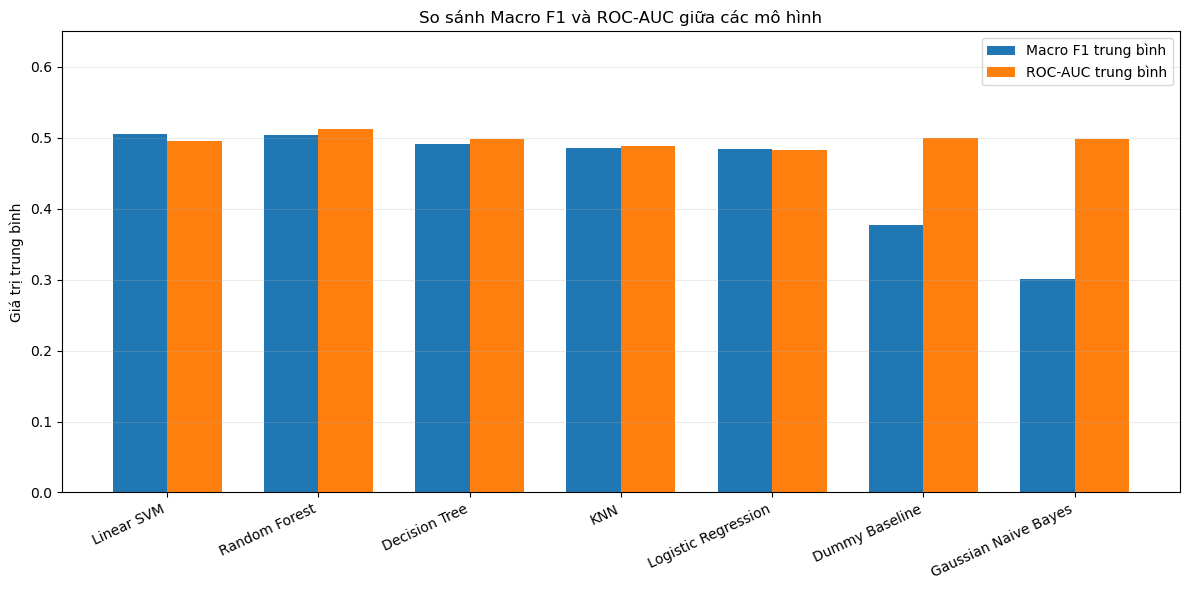

In [44]:
# ============================================================
# HÌNH 5.1 – SO SÁNH MACRO F1 VÀ ROC-AUC TRUNG BÌNH
# ============================================================

plot_compare = (
    average_results
    .sort_values("Macro_F1_mean", ascending=False)
    .copy()
)

x = np.arange(len(plot_compare))
width = 0.36

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_compare["Macro_F1_mean"],
    width=width,
    label="Macro F1 trung bình"
)

plt.bar(
    x + width / 2,
    plot_compare["ROC_AUC_mean"],
    width=width,
    label="ROC-AUC trung bình"
)

plt.xticks(
    x,
    plot_compare["Model"],
    rotation=25,
    ha="right"
)

plt.ylabel("Giá trị trung bình")
plt.title("So sánh Macro F1 và ROC-AUC giữa các mô hình")
plt.ylim(0, 0.65)
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "hinh_5_1_macro_f1_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Nhận xét
Linear SVM và Random Forest là hai mô hình có kết quả tổng thể tốt nhất. Linear SVM nhỉnh hơn về Macro F1, trong khi Random Forest có ROC-AUC cao hơn. Dummy Baseline và Gaussian Naive Bayes có kết quả thiếu cân bằng, cho thấy Accuracy hoặc một chỉ tiêu đơn lẻ không đủ để đánh giá chất lượng mô hình.


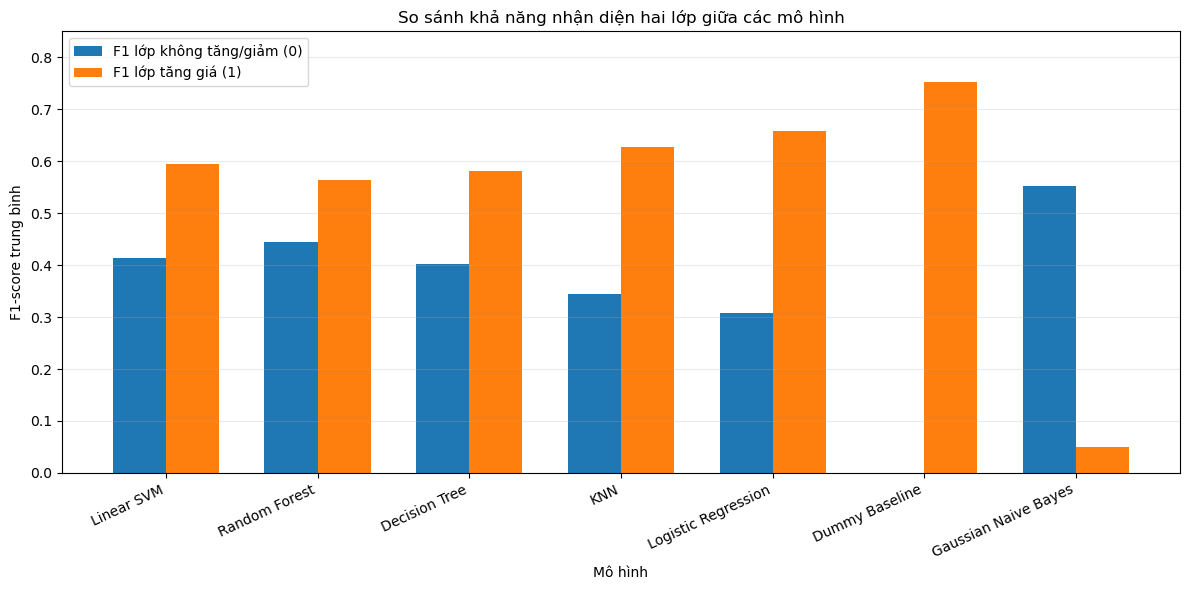

In [45]:
# ============================================================
# HÌNH 5.2 – SO SÁNH F1 CỦA HAI LỚP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plot_f1 = (
    average_results
    .sort_values(
        "Macro_F1_mean",
        ascending=False
    )
    .copy()
)

x = np.arange(len(plot_f1))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_f1["F1_0_mean"],
    width=width,
    label="F1 lớp không tăng/giảm (0)"
)

plt.bar(
    x + width / 2,
    plot_f1["F1_1_mean"],
    width=width,
    label="F1 lớp tăng giá (1)"
)

plt.xticks(
    x,
    plot_f1["Model"],
    rotation=25,
    ha="right"
)

plt.xlabel("Mô hình")
plt.ylabel("F1-score trung bình")

plt.title(
    "So sánh khả năng nhận diện hai lớp giữa các mô hình"
)

plt.ylim(0, 0.85)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "hinh_5_2_so_sanh_f1_hai_lop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Nhận xét
Phần lớn mô hình nhận diện lớp tăng tốt hơn lớp không tăng. Random Forest và Linear SVM có mức chênh lệch giữa F1 hai lớp thấp hơn Logistic Regression và KNN, trong khi Dummy Baseline và Gaussian Naive Bayes thể hiện sự thiên lệch rất rõ về một lớp.


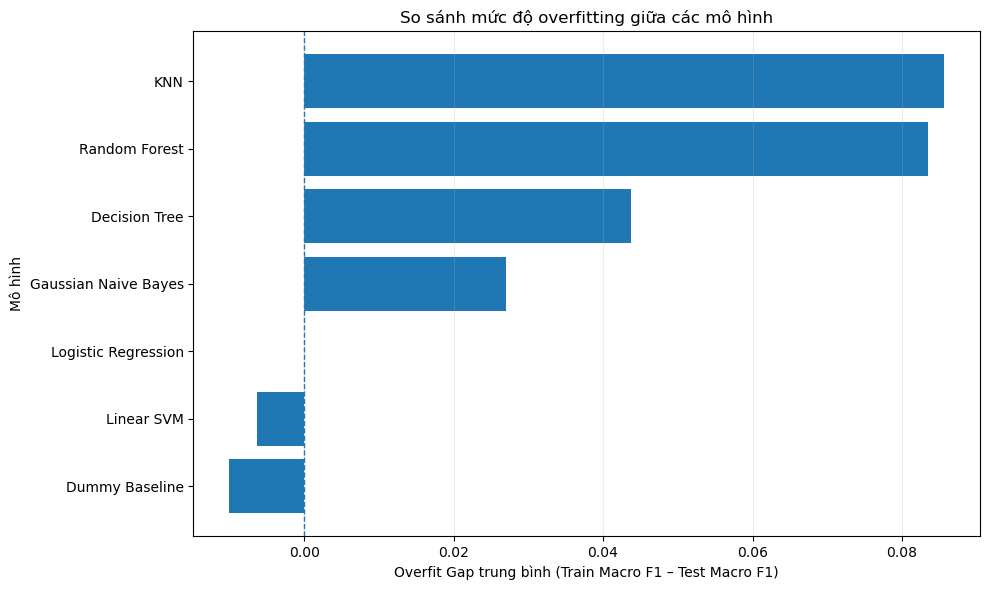

In [46]:
# ============================================================
# HÌNH 5.3 – OVERFIT GAP TRUNG BÌNH
# ============================================================

import matplotlib.pyplot as plt

plot_gap = (
    average_results
    .sort_values(
        "Overfit_Gap_mean",
        ascending=True
    )
    .copy()
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_gap["Model"],
    plot_gap["Overfit_Gap_mean"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Overfit Gap trung bình "
    "(Train Macro F1 – Test Macro F1)"
)

plt.ylabel("Mô hình")

plt.title(
    "So sánh mức độ overfitting giữa các mô hình"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "hinh_5_3_overfit_gap_trung_binh.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Nhận xét
Linear SVM và Logistic Regression có Overfit Gap gần bằng 0, cho thấy kết quả khá ổn định giữa train và test. KNN và Random Forest có khoảng cách lớn hơn, phản ánh nguy cơ overfitting cao hơn. Tuy nhiên, Overfit Gap thấp không đồng nghĩa mô hình tốt nếu hiệu quả trên cả hai tập đều thấp.


In [47]:
# ============================================================
# 21. CHỌN MÔ HÌNH DỰA TRÊN GIAI ĐOẠN 2022–2023
# ============================================================

selection_results = (
    all_results[
        (all_results["Test_Year"].isin([2022, 2023]))
        & (all_results["Model"] != "Dummy Baseline")
    ]
    .groupby("Model")
    .agg({
        "Macro_F1": "mean",
        "ROC_AUC": "mean",
        "Recall_0": "mean",
        "Overfit_Gap": "mean"
    })
    .reset_index()
    .sort_values(
        [
            "Macro_F1",
            "ROC_AUC",
            "Recall_0"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(selection_results)

best_model_row = selection_results.iloc[0]
best_model_name = best_model_row["Model"]

print(
    "Mô hình được lựa chọn từ kết quả 2022–2023:",
    best_model_name
)

print(
    "Macro F1 trung bình giai đoạn lựa chọn:",
    round(best_model_row["Macro_F1"], 4)
)

print(
    "ROC-AUC trung bình giai đoạn lựa chọn:",
    round(best_model_row["ROC_AUC"], 4)
)

print(
    "Overfit Gap trung bình:",
    round(best_model_row["Overfit_Gap"], 4)
)

if best_model_row["ROC_AUC"] <= 0.55:
    print(
        "Lưu ý: Khả năng phân biệt hai lớp vẫn còn yếu "
        "do ROC-AUC gần mức 0.5."
    )

,Model,Macro_F1,ROC_AUC,Recall_0,Overfit_Gap
0,Linear SVM,0.5082,0.5095,0.4865,-0.0074
1,Random Forest,0.5029,0.5162,0.5062,0.0912
2,KNN,0.4952,0.4904,0.3344,0.0770
3,Decision Tree,0.4942,0.5039,0.4609,0.0404
4,Logistic Regression,0.4863,0.4966,0.2152,-0.0071
5,Gaussian Naive Bayes,0.3005,0.5079,0.9479,0.0333


Mô hình được lựa chọn từ kết quả 2022–2023: Linear SVM
Macro F1 trung bình giai đoạn lựa chọn: 0.5082
ROC-AUC trung bình giai đoạn lựa chọn: 0.5095
Overfit Gap trung bình: -0.0074
Lưu ý: Khả năng phân biệt hai lớp vẫn còn yếu do ROC-AUC gần mức 0.5.


### Nhận xét
Kết quả của các mô hình không chênh lệch lớn và ROC-AUC chủ yếu dao động quanh 0,5. Điều này cho thấy các chỉ tiêu tài chính năm chỉ giải thích được một phần xu hướng giá cổ phiếu. Trên thực tế, giá còn phản ánh kỳ vọng của nhà đầu tư, thông tin đã được thị trường hấp thụ, biến động lãi suất, chính sách tiền tệ và dòng tiền. Ngoài ra, việc gộp doanh nghiệp thuộc nhiều ngành vào cùng một mô hình có thể làm giảm khả năng phát hiện những mối quan hệ đặc thù. Vì vậy, kết quả chưa cao không chỉ xuất phát từ thuật toán mà còn liên quan đến phạm vi biến đầu vào và tính biến động của dữ liệu chứng khoán.


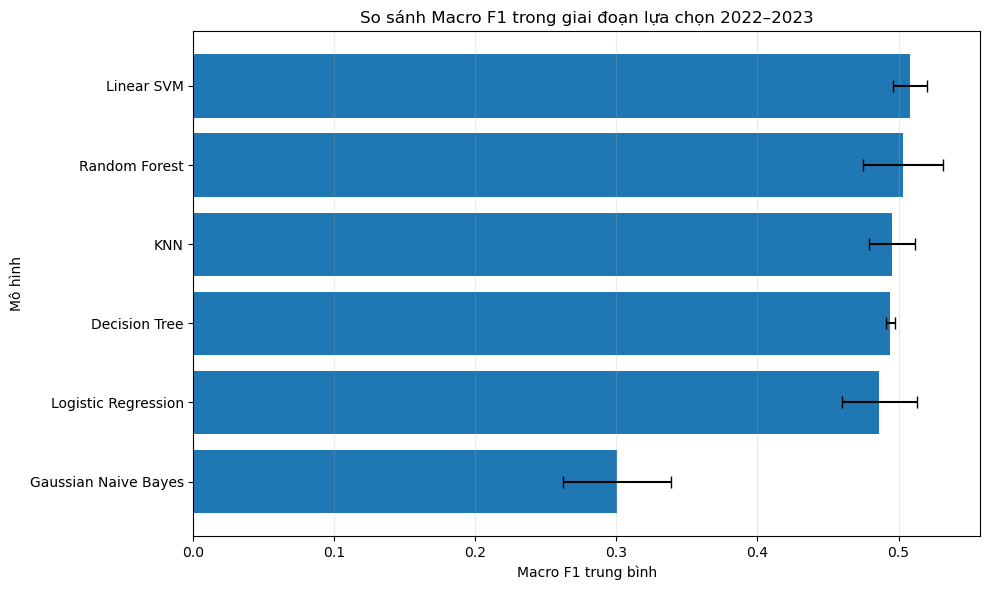

,Model,Macro_F1_mean,Macro_F1_std
3,Linear SVM,0.5082,0.0121
5,Random Forest,0.5029,0.0283
2,KNN,0.4952,0.0162
0,Decision Tree,0.4942,0.0034
4,Logistic Regression,0.4863,0.0265
1,Gaussian Naive Bayes,0.3005,0.0384


In [48]:
# ============================================================
# HÌNH 5.4 – MACRO F1 TRUNG BÌNH GIAI ĐOẠN LỰA CHỌN 2022–2023
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Chỉ sử dụng năm 2022–2023 để lựa chọn mô hình
selection_plot = (
    all_results[
        (all_results["Test_Year"].isin([2022, 2023]))
        & (all_results["Model"] != "Dummy Baseline")
    ]
    .groupby("Model", as_index=False)
    .agg(
        Macro_F1_mean=("Macro_F1", "mean"),
        Macro_F1_std=("Macro_F1", "std")
    )
    .sort_values(
        "Macro_F1_mean",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    selection_plot["Model"],
    selection_plot["Macro_F1_mean"],
    xerr=selection_plot["Macro_F1_std"],
    capsize=4
)

plt.xlabel("Macro F1 trung bình")
plt.ylabel("Mô hình")

plt.title(
    "So sánh Macro F1 trong giai đoạn lựa chọn 2022–2023"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "hinh_5_4_lua_chon_mo_hinh_2022_2023.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(
    selection_plot.sort_values(
        "Macro_F1_mean",
        ascending=False
    )
)

### Nhận xét
Linear SVM chỉ nhỉnh hơn Random Forest một khoảng nhỏ về Macro F1. Vì vậy, kết quả lựa chọn không cho thấy ưu thế tuyệt đối, nhưng Linear SVM phù hợp hơn khi xét đồng thời hiệu quả và tính ổn định.


In [49]:
# ============================================================
# 22. LẤY KẾT QUẢ MÔ HÌNH TỐT NHẤT
# ============================================================

prediction_dictionary = {
    "Logistic Regression":
        logistic_predictions,

    "KNN":
        knn_predictions,

    "Gaussian Naive Bayes":
        naive_bayes_predictions,

    "Decision Tree":
        decision_tree_predictions,

    "Random Forest":
        random_forest_predictions,

    "Linear SVM":
        linear_svm_predictions
}

fitted_model_dictionary = {
    "Logistic Regression":
        logistic_fitted_models,

    "KNN":
        knn_fitted_models,

    "Gaussian Naive Bayes":
        naive_bayes_fitted_models,

    "Decision Tree":
        decision_tree_fitted_models,

    "Random Forest":
        random_forest_fitted_models,

    "Linear SVM":
        linear_svm_fitted_models
}

final_predictions = (
    prediction_dictionary[
        best_model_name
    ].copy()
)

best_fitted_models = (
    fitted_model_dictionary[
        best_model_name
    ]
)

In [50]:
# ============================================================
# 23. BÁO CÁO CHI TIẾT NĂM 2024
# ============================================================

final_2024 = final_predictions[
    final_predictions["Year"] == 2024
].copy()

y_true_2024 = (
    final_2024["Target_Up"]
)

y_pred_2024 = (
    final_2024["Predicted_Class"]
)

print(
    f"MÔ HÌNH: {best_model_name}"
)

print(
    classification_report(
        y_true_2024,
        y_pred_2024,
        target_names=[
            "Không tăng hoặc giảm (0)",
            "Tăng giá (1)"
        ],
        zero_division=0
    )
)

print("Confusion Matrix:")

print(
    confusion_matrix(
        y_true_2024,
        y_pred_2024
    )
)

MÔ HÌNH: Linear SVM
                          precision    recall  f1-score   support

Không tăng hoặc giảm (0)       0.43      0.34      0.38       300
            Tăng giá (1)       0.57      0.67      0.62       397

                accuracy                           0.53       697
               macro avg       0.50      0.50      0.50       697
            weighted avg       0.51      0.53      0.51       697

Confusion Matrix:
[[101 199]
 [132 265]]


### Nhận xét
Trên năm 2024, Linear SVM dự báo đúng 265 cổ phiếu tăng và 101 cổ phiếu không tăng. Mô hình có 199 False Positive và 132 False Negative. Số False Positive cao cho thấy nguy cơ lựa chọn nhầm cổ phiếu vẫn đáng kể nếu sử dụng dự báo như tín hiệu mua độc lập.


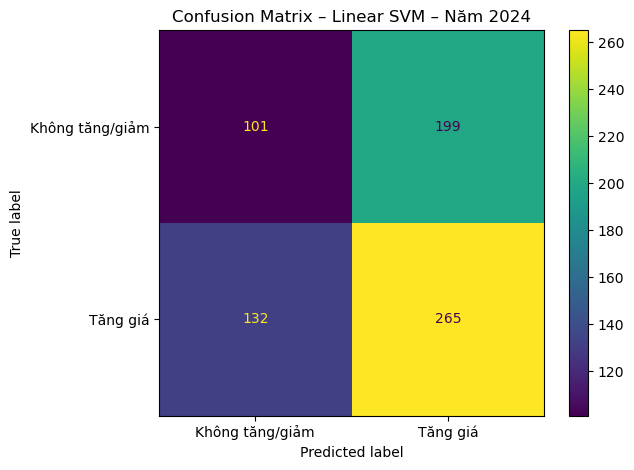

In [51]:
ConfusionMatrixDisplay.from_predictions(
    y_true_2024,
    y_pred_2024,
    display_labels=[
        "Không tăng/giảm",
        "Tăng giá"
    ],
    values_format="d"
)

plt.title(
    f"Confusion Matrix – {best_model_name} – Năm 2024"
)

plt.tight_layout()
plt.show()

### Nhận xét
Ma trận nhầm lẫn xác nhận mô hình thiên về dự báo lớp tăng. Khả năng nhận diện cổ phiếu không tăng còn thấp hơn rõ rệt, nên kết quả phù hợp hơn cho bước sàng lọc ban đầu thay vì quyết định giải ngân cuối cùng.


In [52]:
# ============================================================
# PHÂN TÍCH SAI LẦM RIÊNG TRÊN NĂM 2024
# ============================================================

error_2024 = final_2024.copy()

error_2024["Prediction_Error"] = np.select(
    [
        (error_2024["Predicted_Class"] == 1)
        & (error_2024["Target_Up"] == 0),

        (error_2024["Predicted_Class"] == 0)
        & (error_2024["Target_Up"] == 1),

        error_2024["Predicted_Class"]
        == error_2024["Target_Up"]
    ],
    [
        "False Positive: dự báo tăng nhưng thực tế không tăng",
        "False Negative: dự báo không tăng nhưng thực tế tăng",
        "Dự báo đúng"
    ],
    default="Không xác định"
)

error_summary_2024 = (
    error_2024["Prediction_Error"]
    .value_counts()
    .rename_axis("Loại kết quả")
    .reset_index(name="Số quan sát")
)

display(error_summary_2024)


,Loại kết quả,Số quan sát
0,Dự báo đúng,366
1,False Positive: dự báo tăng nhưng thực tế khôn...,199
2,False Negative: dự báo không tăng nhưng thực t...,132


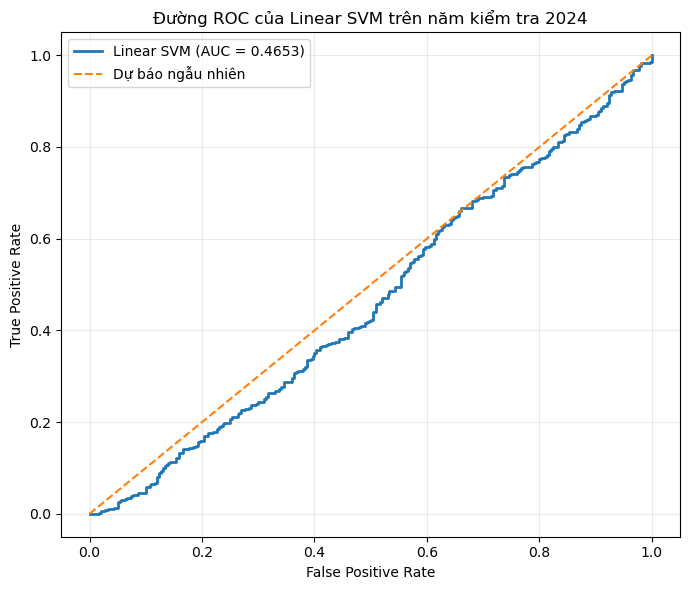

In [53]:
# ============================================================
# HÌNH 5.5 – ROC CURVE CỦA LINEAR SVM NĂM 2024
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Lọc dự báo Linear SVM năm 2024
linear_svm_2024 = linear_svm_predictions[
    linear_svm_predictions["Year"] == 2024
].copy()

y_true_2024 = linear_svm_2024[TARGET].astype(int)
y_score_2024 = linear_svm_2024["Score_Up"].astype(float)

# Tính ROC
fpr, tpr, thresholds = roc_curve(
    y_true_2024,
    y_score_2024
)

roc_auc_value = roc_auc_score(
    y_true_2024,
    y_score_2024
)

# Vẽ biểu đồ
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Linear SVM (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Dự báo ngẫu nhiên"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Đường ROC của Linear SVM trên năm kiểm tra 2024"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "hinh_5_5_roc_linear_svm_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Nhận xét
ROC-AUC của Linear SVM năm 2024 đạt 0,4653 và đường ROC phần lớn nằm gần hoặc dưới đường dự báo ngẫu nhiên. Điều này cho thấy khả năng phân biệt và xếp hạng hai lớp trên năm kiểm tra cuối còn yếu.


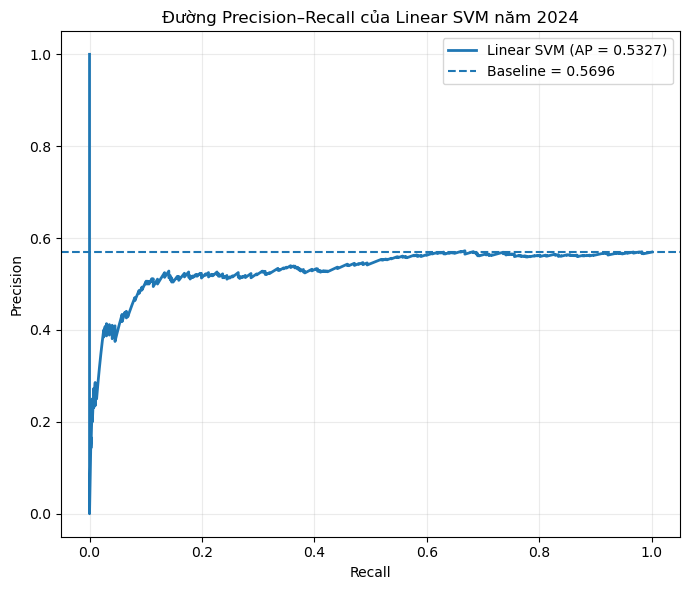

In [54]:
# ============================================================
# HÌNH 5.6 – PRECISION–RECALL CURVE CỦA LINEAR SVM NĂM 2024
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_true_2024,
        y_score_2024
    )
)

ap_value = average_precision_score(
    y_true_2024,
    y_score_2024
)

# Tỷ lệ lớp tăng trong dữ liệu để làm baseline
positive_rate = y_true_2024.mean()

plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"Linear SVM (AP = {ap_value:.4f})"
)

plt.axhline(
    y=positive_rate,
    linestyle="--",
    label=f"Baseline = {positive_rate:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Đường Precision–Recall của Linear SVM năm 2024"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "hinh_5_6_precision_recall_linear_svm_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Nhận xét
Average Precision đạt 0,5327, thấp hơn baseline 0,5696. Khi mở rộng phạm vi nhận diện cổ phiếu tăng, độ chính xác của các dự báo tăng chưa được duy trì tốt.


In [55]:
# ============================================================
# 26. PERMUTATION IMPORTANCE
# ============================================================

last_test_year = 2024

(
    X_train_last,
    X_test_last,
    y_train_last,
    y_test_last,
    train_data_last,
    test_data_last
) = create_train_test_by_year(
    model_df,
    last_test_year,
    FEATURES,
    TARGET
)

best_model_2024 = (
    best_fitted_models[
        last_test_year
    ]
)

permutation_result = permutation_importance(
    estimator=best_model_2024,
    X=X_test_last,
    y=y_test_last,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

In [56]:
permutation_table = pd.DataFrame({
    "Biến":
        FEATURES,

    "Importance_Mean":
        permutation_result.importances_mean,

    "Importance_Std":
        permutation_result.importances_std
})

permutation_table = (
    permutation_table
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(permutation_table)

,Biến,Importance_Mean,Importance_Std
0,CR,0.0217,0.0113
1,Size,0.0120,0.0080
2,DR,0.0021,0.0037
3,Asset_Growth,0.0019,0.0038
4,ROA,0.0018,0.0155
5,LNST,0.0007,0.0017
6,profit_growth,-0.0003,0.0013


### Nhận xét
CR và Size là hai biến có mức đóng góp dự báo lớn nhất theo Permutation Importance. DR và Asset_Growth có đóng góp dương nhưng nhỏ; LNST và profit_growth gần như không làm thay đổi Macro F1. ROA có mức trung bình gần 0 nhưng độ biến động lớn, cho thấy vai trò chưa ổn định.


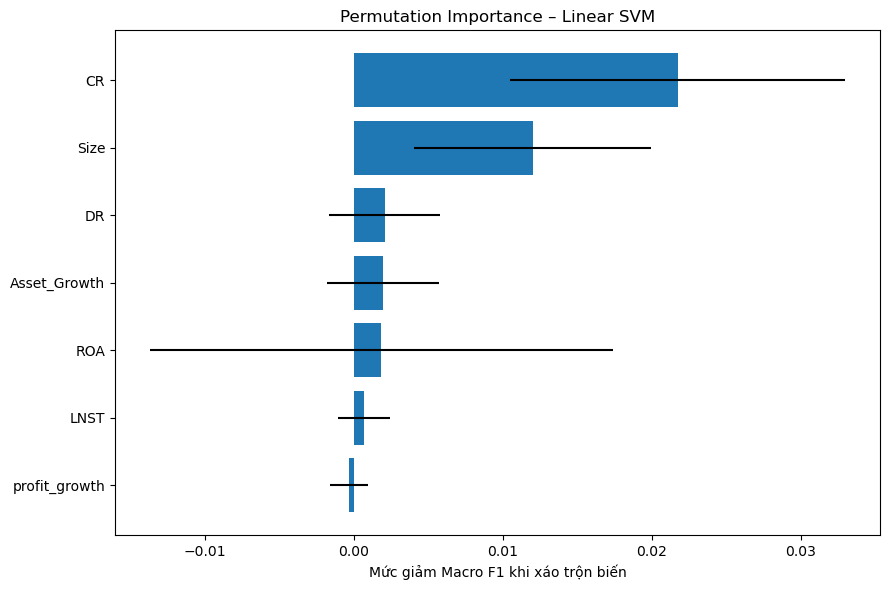

In [57]:
plot_importance = (
    permutation_table
    .sort_values(
        "Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_importance["Biến"],
    plot_importance["Importance_Mean"],
    xerr=plot_importance["Importance_Std"]
)

plt.xlabel(
    "Mức giảm Macro F1 khi xáo trộn biến"
)

plt.title(
    f"Permutation Importance – {best_model_name}"
)

plt.tight_layout()
plt.show()

### Lưu ý khi diễn giải
Permutation Importance phản ánh mức độ hữu ích của biến đối với mô hình trên tập kiểm tra năm 2024, không chứng minh quan hệ nhân quả. Giá trị âm nhẹ có thể cho thấy biến tạo nhiễu hoặc chưa được mô hình khai thác ổn định, chứ không có nghĩa biến đó làm giá cổ phiếu giảm.
